In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# JTI Batch 12 Data
data_dt1 = {
    'Attendance_Per': [85, 45, 90, 30, 95, 50, 80, 40, 88, 35],
    'Typing_Speed': [45, 20, 55, 25, 60, 22, 50, 18, 52, 21],
    'Passed': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0] # 1=Pass, 0=Fail
}
df_tree = pd.DataFrame(data_dt1)



In [2]:
df_tree

,Attendance_Per,Typing_Speed,Passed
0,85,45,1
1,45,20,0
2,90,55,1
3,30,25,0
4,95,60,1
5,50,22,0
6,80,50,1
7,40,18,0
8,88,52,1
9,35,21,0


In [3]:
X=df_tree.drop('Passed',axis=1)
y=df_tree['Passed']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)
final_model=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=42)
final_model.fit(X_train_scaled,y_train)
pred=final_model.predict(X_test_scaled)
print(f"accuracy : {accuracy_score(y_test,pred)*100:.2f}%")
print(f"classification report : {classification_report(y_test,pred)}")

accuracy : 100.00%
classification report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



[Text(0.5, 0.75, 'Attendance_Per <= 0.074\ngini = 0.5\nsamples = 8\nvalue = [4, 4]\nclass = Fail'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = Fail'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = Pass')]

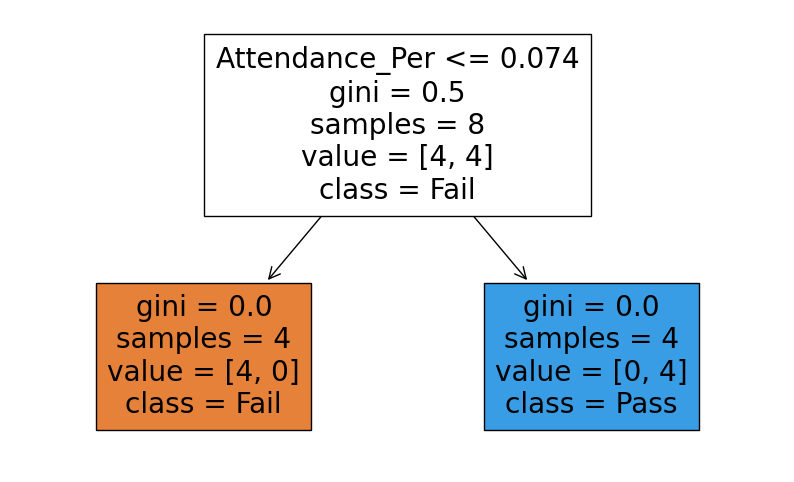

In [12]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
tree.plot_tree(final_model,filled=True,feature_names=list(X.columns),class_names=['Fail','Pass'])

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor # Notice: Classifier nahi, REGRESSOR hai!
from sklearn.metrics import mean_squared_error

# JTI Typing Speed Prediction Data (Continuous Output)
data_reg = {
    'Age': [18, 22, 25, 19, 24, 28, 21, 20, 23, 26],
    'Attendance_Per': [85, 45, 90, 30, 95, 50, 80, 40, 88, 35],
    'Speed_WPM': [45, 20, 55, 15, 60, 22, 50, 18, 52, 25] # Target: Exact speed
}
df_reg = pd.DataFrame(data_reg)




In [14]:
df_reg

,Age,Attendance_Per,Speed_WPM
0,18,85,45
1,22,45,20
2,25,90,55
3,19,30,15
4,24,95,60
5,28,50,22
6,21,80,50
7,20,40,18
8,23,88,52
9,26,35,25


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
X=df_reg.drop('Speed_WPM',axis=1)
y=df_reg['Speed_WPM']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)
final_mod=DecisionTreeRegressor(max_depth=3,min_samples_split=4,min_samples_leaf=2,random_state=42)
final_mod.fit(X_train_scaled,y_train)
predi=final_mod.predict(X_test_scaled)
print(f"the rsme score is : {np.sqrt(mean_squared_error(y_test,predi)):.2f}")
print(f"the r2 score is : {r2_score(y_test,predi)*100:.2f}%")

the rsme score is : 4.61
the r2 score is : 91.70%


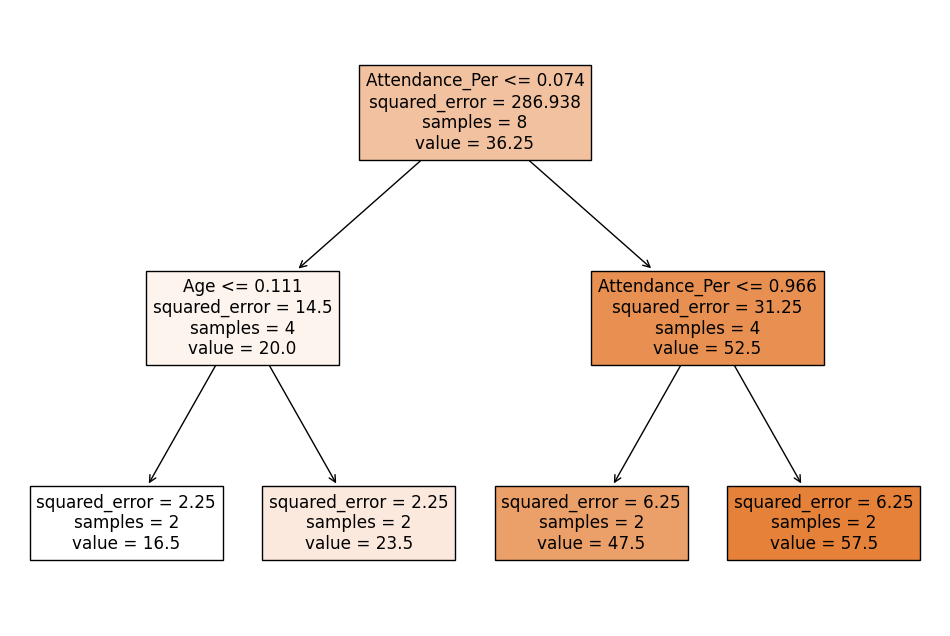

In [24]:
plt.figure(figsize=(12,8))
tree.plot_tree(final_mod,filled=True,feature_names=list(X.columns))
plt.show()

In [25]:
train_pred=final_mod.predict(X_train_scaled)
test_pred=final_mod.predict(X_test_scaled)
print(f"train r2 prediction score: {r2_score(y_train,train_pred)*100:.2f}%")
print(f"test r2 prediction score: {r2_score(y_test,test_pred)*100:.2f}%")

train r2 prediction score: 98.52%
test r2 prediction score: 91.70%
